# BINGCHILLING SKIBIDI

### Data frames

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, SVMSMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, NearMiss, TomekLinks
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import precision_score, recall_score, classification_report, accuracy_score, f1_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

In [3]:
df = pd.read_csv("CSL/train_csl.csv")
tk_cla = pd.read_csv("CSL/test_csl_cla_x.csv")
tk_reg = pd.read_csv("CSL/test_csl_reg_x.csv")

display(df.head(5))
display(df.describe())

,user_age_group,user_id,attempt_date,gender,smt_rank,smt_avg_spd,smt_finish_seconds,smt_name,user_weight_category,act_title,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id
0,25 to 34,1972,2017-12-22,male,712,15.8,382,Headquarters Business Park,54 kg and under,Night Ride,13.6,34.9,19.24,5103,5103,0,6977
1,25 to 34,239,2015-04-13,male,189,33.2,216,Oghor 2 SailsIsland,105 kg to 114 kg,Night Ride,21.5,43.2,23.47,3926,3926,0,3518
2,25 to 34,405,2018-02-07,male,264,23.7,593,Starbucks to Majid,75 to 84 kg,Evening Ride,26.7,92.9,38.23,5152,5152,0,415
3,25 to 34,318,2018-08-24,male,50,33.4,817,Al Fardoos to shellfish round about,75 to 84 kg,Afternoon Ride,31.4,54.4,65.77,7548,7548,1,1755
4,25 to 34,628,2020-03-06,female,19,21.3,284,Headquarters Business Park,54 kg and under,ثاني تمرين ١٠٠كم,19.9,43.2,96.53,17493,17493,0,7088


,user_id,smt_rank,smt_avg_spd,smt_finish_seconds,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id
count,6292.000000,6292.000000,6292.00000,6292.000000,6292.000000,6292.000000,6292.000000,6.292000e+03,6.292000e+03,6292.000000,6292.000000
mean,782.421964,172.515893,26.80925,531.276224,22.681024,44.757533,42.147134,1.252379e+04,1.252379e+04,0.196440,3947.028608
std,539.051866,173.487689,8.44806,431.974886,5.851547,17.055338,27.010789,2.157781e+05,2.157781e+05,0.397337,2261.820409
min,2.000000,1.000000,0.80000,112.000000,0.000000,8.600000,2.280000,2.640000e+02,2.640000e+02,0.000000,1.000000
25%,335.000000,37.000000,21.30000,266.000000,18.700000,36.700000,23.440000,4.095000e+03,4.095000e+03,0.000000,2004.750000
50%,703.500000,108.000000,26.50000,439.000000,22.100000,42.100000,37.780000,5.781500e+03,5.781500e+03,0.000000,3941.000000
75%,1096.000000,267.000000,32.50000,651.000000,26.400000,48.600000,52.140000,8.098500e+03,8.098500e+03,0.000000,5907.250000
max,2254.000000,805.000000,87.30000,9224.000000,75.200000,690.800000,706.590000,1.167978e+07,1.167978e+07,1.000000,7863.000000


### Functions

In [4]:
def check_outlier(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)

    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5*IQR
    upper_limit = Q3 + 1.5*IQR

    outliers = (df < lower_limit) | (df > upper_limit)
    print ("Outlier pada tiap atribut:")
    print(outliers.sum())

    return outliers

def check_null(df):
    col_na = df.isnull().sum().sort_values(ascending=True)
    percent = col_na / len(df)
    missing_data = pd.concat([col_na, percent], axis=1, keys=['Total', 'Percent'])

    if (missing_data[missing_data['Total'] > 0].shape[0] == 0):
        print("Tidak ditemukan missing value pada dataset")
    else:
        print(missing_data[missing_data['Total'] > 0])

def plot_datasets_for_comparison(X1, y1, title1, X2, y2, title2, figsize=(16, 6)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    axes[0].scatter(X1[y1 == 0][:, 0], X1[y1 == 0][:, 1], label='Class 0 (Majority)')
    axes[0].scatter(X1[y1 == 1][:, 0], X1[y1 == 1][:, 1], label='Class 1 (Minority)')
    axes[0].set_title(title1, fontsize=14)
    axes[0].set_xlabel('Feature 1')
    axes[0].set_ylabel('Feature 2')
    axes[0].legend()

    axes[1].scatter(X2[y2 == 0][:, 0], X2[y2 == 0][:, 1], label='Class 0 (Majority)')
    axes[1].scatter(X2[y2 == 1][:, 0], X2[y2 == 1][:, 1], label='Class 1 (Minority)')
    axes[1].set_title(title2, fontsize=14)
    axes[1].set_xlabel('Feature 1')
    axes[1].set_ylabel('Feature 2')
    axes[1].legend()

    x_min = min(X1[:, 0].min(), X2[:, 0].min())
    x_max = max(X1[:, 0].max(), X2[:, 0].max())
    y_min = min(X1[:, 1].min(), X2[:, 1].min())
    y_max = max(X1[:, 1].max(), X2[:, 1].max())

    axes[0].set_xlim(x_min, x_max)
    axes[0].set_ylim(y_min, y_max)
    axes[1].set_xlim(x_min, x_max)
    axes[1].set_ylim(y_min, y_max)

    plt.tight_layout()
    plt.show()

def plot_single_dataset(X, y, title, figsize=(8, 6)):
    plt.figure(figsize=figsize)
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label='Class 0 (Majority)')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label='Class 1 (Minority)')
    plt.title(title, fontsize=14)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.show()

def plot_boxplot(data, column):
    """
    Plots a boxplot for the specified column in the dataset.
    """
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=data[column], color='skyblue')
    plt.title(f'Boxplot of {column}', fontsize=14)
    plt.xlabel(column, fontsize=12)
    plt.show()


In [5]:
# evaluation helper function
def evaluate_classifier_performance(prediction, y_test):
    # Informasi evaluasi secara compact
    print("Hasil Evaluasi berdasarkan classification report \n\n%s\n" % (classification_report(y_test, prediction,zero_division=0)))
    print()
    print("Confusion Matrix")
    print()
    y_actual = pd.Series(np.array(y_test), name = "actual")
    y_pred = pd.Series(np.array(prediction), name = "prediction")
    df_confusion = pd.crosstab(y_actual, y_pred)
    display(df_confusion)
    print()
    print()

    print("Butuh informasi lebih lengkap? silakan simak di bawah ini : ")
    print('Accuracy Average:', accuracy_score(y_test, prediction))
    print('F1 Macro Average:', f1_score(y_test, prediction, average='macro'))
    print('F1 Micro Average:', f1_score(y_test, prediction, average='micro'))
    print('Precision Macro Average:', precision_score(y_test, prediction, average='macro',zero_division=0))
    print('Precision Micro Average:', precision_score(y_test, prediction, average='micro',zero_division=0))
    print('Recall Macro Average:', recall_score(y_test, prediction, average='macro',zero_division=0))
    print('Recall Micro Average:', recall_score(y_test, prediction, average='micro',zero_division=0))
    print()

def evaluate_regression_performance(y_predict, y_test):
    print("R-squared:", r2_score(y_test, y_predict))
    print("MAE:", mean_absolute_error(y_test, y_predict))
    print("MSE:", mean_squared_error(y_test, y_predict))
    print("RMSE:", root_mean_squared_error(y_test, y_predict))

### Preprocess

In [6]:
Counter(df['gender'])

Counter({'male': 6039, 'female': 253})

In [7]:
preproc_df = df.copy()

In [8]:
preproc_df = preproc_df.drop(columns=['user_id','id'])

In [9]:
check_null(preproc_df)
dict(check_outlier(preproc_df.copy().select_dtypes(include=[np.number])).sum())
print("Jumlah duplikasi data : " + str(preproc_df.duplicated().sum()))

                      Total   Percent
user_weight_category    360  0.057216
Outlier pada tiap atribut:
smt_rank               163
smt_avg_spd             53
smt_finish_seconds     288
act_avg_spd             94
act_max_spd            375
act_total_km           308
act_moving_seconds     296
act_total_seconds      296
has_hr_data           1236
dtype: int64
Jumlah duplikasi data : 38


In [10]:
num_cols = preproc_df.select_dtypes(include=np.number).columns
cat_cols = preproc_df.select_dtypes(include=object).columns

# keyword: check unique
print("Menampilkan nilai unique yang terdapat pada setiap kolom kategorikal")
for col in cat_cols:
    print(col, f": {len(preproc_df[col].unique())}", preproc_df[col].unique())

Menampilkan nilai unique yang terdapat pada setiap kolom kategorikal
user_age_group : 9 ['25 to 34' '19 and under' '35 to 44' '55 to 64' '45 to 54' '20 to 24'
 '65 to 69' '75+' '70 to 74']
attempt_date : 1457 ['2017-12-22' '2015-04-13' '2018-02-07' ... '2016-04-21' '2019-08-31'
 '2019-04-25']
gender : 2 ['male' 'female']
smt_name : 9 ['Headquarters Business Park' 'Oghor 2 SailsIsland' 'Starbucks to Majid'
 'Al Fardoos to shellfish round about' 'North Corniche' 'King Street side'
 'S.Ubhur Alkurnaysh South Bound with detour' 'Obhur North Short'
 'PRINCE SULTAN - ASSALAM TO FATIMA']
user_weight_category : 9 ['54 kg and under' '105 kg to 114 kg' '75 to 84 kg' '65 to 74 kg'
 '115 kg and over' '85 to 95 kg' '95 kg to 104 kg' nan '55 to 64 kg']
act_title : 1051 ['Night Ride' 'Evening Ride' 'Afternoon Ride' ...
 'Evening Ride مسائي للوحوش' 'Evening Ride With Jeddah Cyclists '
 'Nice Relaxed Ride next the Red Sea']


<!-- #### Acts -->

##### feature selection

In [11]:
preproc_df = preproc_df.drop(columns=['attempt_date','act_title'])
display(preproc_df.head(5))

,user_age_group,gender,smt_rank,smt_avg_spd,smt_finish_seconds,smt_name,user_weight_category,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data
0,25 to 34,male,712,15.8,382,Headquarters Business Park,54 kg and under,13.6,34.9,19.24,5103,5103,0
1,25 to 34,male,189,33.2,216,Oghor 2 SailsIsland,105 kg to 114 kg,21.5,43.2,23.47,3926,3926,0
2,25 to 34,male,264,23.7,593,Starbucks to Majid,75 to 84 kg,26.7,92.9,38.23,5152,5152,0
3,25 to 34,male,50,33.4,817,Al Fardoos to shellfish round about,75 to 84 kg,31.4,54.4,65.77,7548,7548,1
4,25 to 34,female,19,21.3,284,Headquarters Business Park,54 kg and under,19.9,43.2,96.53,17493,17493,0


In [12]:
cat_cols

Index(['user_age_group', 'attempt_date', 'gender', 'smt_name',
       'user_weight_category', 'act_title'],
      dtype='object')

In [13]:
# Convert to list type
cat_cols = list(cat_cols)

if 'attempt_date' in cat_cols:
    cat_cols.remove('attempt_date')
if 'act_title' in cat_cols:
    cat_cols.remove('act_title')

# Convert back to Index type
cat_cols = pd.Index(cat_cols)

cat_cols

Index(['user_age_group', 'gender', 'smt_name', 'user_weight_category'], dtype='object')

##### nulls

In [14]:
df_if_drop_na = preproc_df.dropna()
check_null(df_if_drop_na)
outliers = dict(check_outlier(df_if_drop_na[num_cols]).sum())
outliers = dict(check_outlier(preproc_df[num_cols]).sum())

Tidak ditemukan missing value pada dataset
Outlier pada tiap atribut:
smt_rank               168
smt_avg_spd             60
smt_finish_seconds     266
act_avg_spd             71
act_max_spd            338
act_total_km           310
act_moving_seconds     257
act_total_seconds      257
has_hr_data           1227
dtype: int64
Outlier pada tiap atribut:
smt_rank               163
smt_avg_spd             53
smt_finish_seconds     288
act_avg_spd             94
act_max_spd            375
act_total_km           308
act_moving_seconds     296
act_total_seconds      296
has_hr_data           1236
dtype: int64


walau tidak banyak, outlier berkurang jika semua null di-drop

In [15]:
preproc_df = df_if_drop_na

##### outliers

In [16]:
outliers = dict(check_outlier(preproc_df[num_cols]).sum())

Outlier pada tiap atribut:
smt_rank               168
smt_avg_spd             60
smt_finish_seconds     266
act_avg_spd             71
act_max_spd            338
act_total_km           310
act_moving_seconds     257
act_total_seconds      257
has_hr_data           1227
dtype: int64


In [17]:
Counter(preproc_df['has_hr_data'])

Counter({0: 4705, 1: 1227})

- kolom 'has_hr_data' perlu resampling bukan outlier handling, dan kolom ini merupakan kolom kategorikal.
- outlier smt_rank bisa diignore, karena berupa rank. Bisa dianggap kategorikal.

In [18]:
# Convert to list type
cat_cols = list(cat_cols)
num_cols = list(num_cols)

misplaced_cat_cols = ['smt_rank', 'has_hr_data']
for col in misplaced_cat_cols:
    if col not in cat_cols:
        cat_cols.append(col)
    if col in num_cols:
        num_cols.remove(col)

# Convert back to Index type
cat_cols = pd.Index(cat_cols)
num_cols = pd.Index(num_cols)

display(cat_cols)
display(num_cols)

Index(['user_age_group', 'gender', 'smt_name', 'user_weight_category',
       'smt_rank', 'has_hr_data'],
      dtype='object')

Index(['smt_avg_spd', 'smt_finish_seconds', 'act_avg_spd', 'act_max_spd',
       'act_total_km', 'act_moving_seconds', 'act_total_seconds'],
      dtype='object')

In [19]:
outliers = dict(check_outlier(preproc_df[num_cols]).sum())

Outlier pada tiap atribut:
smt_avg_spd            60
smt_finish_seconds    266
act_avg_spd            71
act_max_spd           338
act_total_km          310
act_moving_seconds    257
act_total_seconds     257
dtype: int64


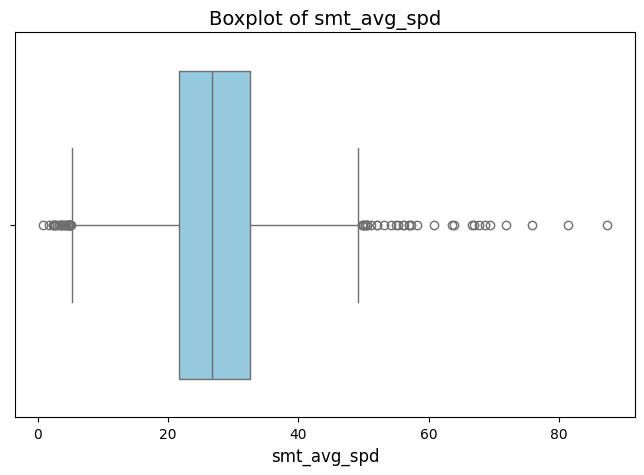

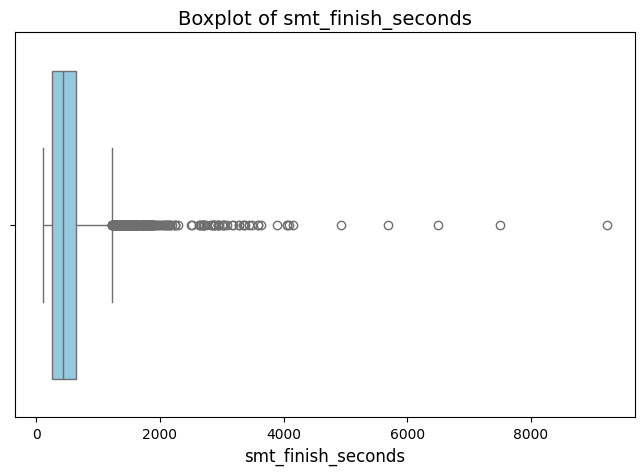

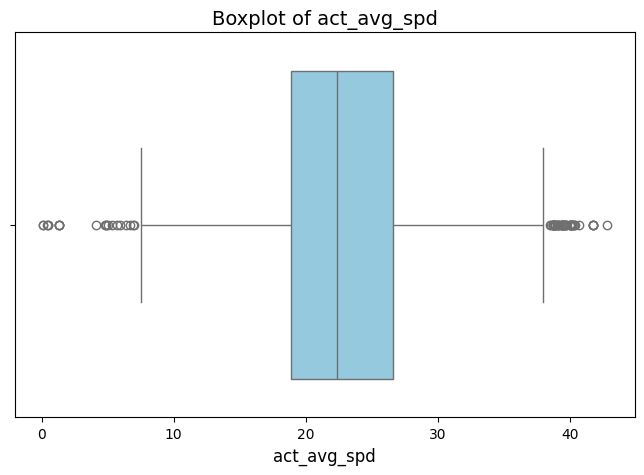

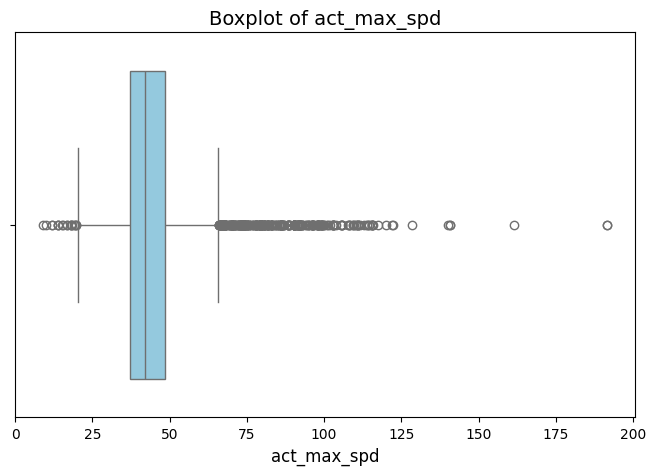

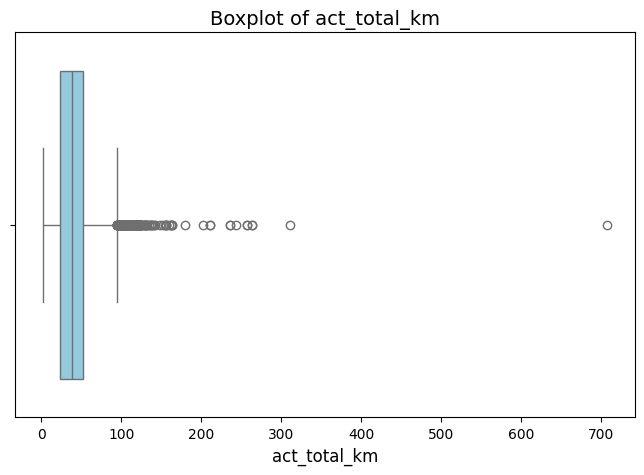

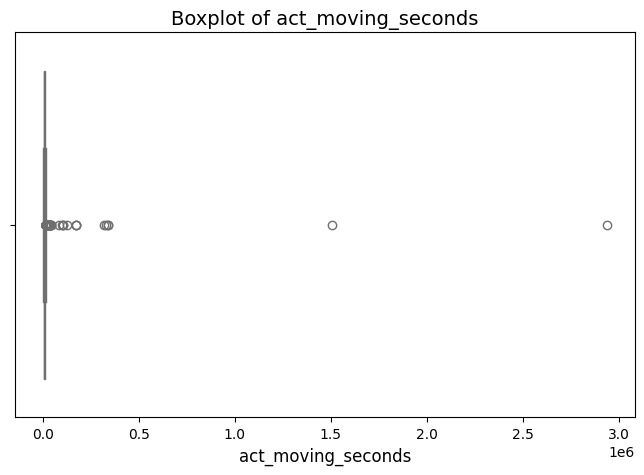

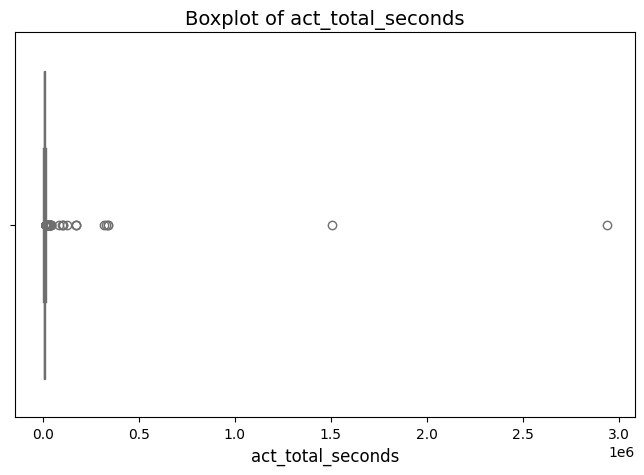

In [20]:
for key in outliers.keys():
    plot_boxplot(preproc_df, key)

> Potential next move based on boxplot
- smt_avg_spd           : Currently no comment, let it be
- smt_finish_seconds    : Currently no comment, let it be
- act_avg_spd           : Currently no comment, let it be
- act_max_spd           : Currently no comment, let it be
- act_total_km          : Check data with extremely high value and drop if necessary, which would be the good move, but for now I'd just keep them.
- act_moving_seconds    : No danger based on how the data spreads, removeable, but ok to keep, I choose keep.
- act_total_seconds     : same as act_moving_seconds

##### encoding

In [21]:
age_map = {
    '19 and under': 0,
    '20 to 24': 1,
    '25 to 34': 2,
    '35 to 44': 3,
    '45 to 54': 4,
    '55 to 64': 5,
    '65 to 69': 6,
    '70 to 74': 7,
    '75+': 8
    }

# why not labelenc? for easy adjustments if needed
gender_map = {
    'female': 0,
    'male': 1
    }

weight_map = {
    '54 kg and under': 0,
    '55 to 64 kg': 1,
    '65 to 74 kg': 2,
    '75 to 84 kg': 3,
    '85 to 95 kg': 4,
    '95 kg to 104 kg': 5,
    '105 kg to 114 kg': 6,
    '115 kg and over': 7
    }


preproc_df['user_age_group'] = preproc_df['user_age_group'].map(age_map)
preproc_df['gender'] = preproc_df['gender'].map(gender_map)
preproc_df['user_weight_category'] = preproc_df['user_weight_category'].map(weight_map)

smtname_enc = LabelEncoder()
preproc_df.loc[:, 'smt_name'] = smtname_enc.fit_transform(preproc_df['smt_name'])

display(preproc_df.head(5))

,user_age_group,gender,smt_rank,smt_avg_spd,smt_finish_seconds,smt_name,user_weight_category,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data
0,2,1,712,15.8,382,1,0,13.6,34.9,19.24,5103,5103,0
1,2,1,189,33.2,216,5,6,21.5,43.2,23.47,3926,3926,0
2,2,1,264,23.7,593,8,3,26.7,92.9,38.23,5152,5152,0
3,2,1,50,33.4,817,0,3,31.4,54.4,65.77,7548,7548,1
4,2,0,19,21.3,284,1,0,19.9,43.2,96.53,17493,17493,0


##### standardize

In [22]:
cla_scaler = MinMaxScaler()
reg_scaler = MinMaxScaler()

scaled_df = preproc_df.copy()
scaled_df[num_cols] = cla_scaler.fit_transform(scaled_df[num_cols])

reg_num_cols = list(num_cols.copy())
if 'smt_finish_seconds' in reg_num_cols:
    reg_num_cols.remove('smt_finish_seconds')
reg_num_cols = pd.Index(reg_num_cols)

reg_scaled_df = preproc_df.copy()
reg_scaled_df[reg_num_cols] = reg_scaler.fit_transform(reg_scaled_df[reg_num_cols])

In [23]:
preproc_df

,user_age_group,gender,smt_rank,smt_avg_spd,smt_finish_seconds,smt_name,user_weight_category,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data
0,2,1,712,15.8,382,1,0,13.6,34.9,19.24,5103,5103,0
1,2,1,189,33.2,216,5,6,21.5,43.2,23.47,3926,3926,0
2,2,1,264,23.7,593,8,3,26.7,92.9,38.23,5152,5152,0
3,2,1,50,33.4,817,0,3,31.4,54.4,65.77,7548,7548,1
4,2,0,19,21.3,284,1,0,19.9,43.2,96.53,17493,17493,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6286,2,1,396,24.2,718,3,0,16.6,34.9,41.34,8970,8970,0
6288,3,1,34,38.9,446,3,4,34.5,52.2,48.13,5026,5026,1
6289,3,1,218,22.1,637,8,3,17.6,40.7,50.64,10374,10374,0
6290,3,1,477,12.4,485,1,4,14.5,34.9,40.93,10158,10158,0


### Training

In [24]:
# class train
X_cla_imbalanced, y_cla_imbalanced = scaled_df.drop(columns=['gender']), scaled_df['gender']
# comment: i want to take into account the outliers, hence svm-smote
svm_smote = SVMSMOTE()
X_cla, y_cla = svm_smote.fit_resample(X_cla_imbalanced, y_cla_imbalanced)

# reg train
X_reg, y_reg = reg_scaled_df.drop(columns=['smt_finish_seconds']), reg_scaled_df['smt_finish_seconds']

In [25]:
X_cla_train, X_cla_test, y_cla_train, y_cla_test = train_test_split(X_cla, y_cla, test_size = 0.27, random_state = 42)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size = 0.2, random_state = 153)

In [26]:
cla_model = LogisticRegression(max_iter=500)
cla_model.fit(X_cla_train, y_cla_train)

LogisticRegression(max_iter=500)

In [27]:
reg_model = RandomForestRegressor()
reg_model.fit(X_reg_train, y_reg_train)

RandomForestRegressor()

### Testing

In [28]:
evaluate_classifier_performance(cla_model.predict(X_cla_test), y_cla_test)

Hasil Evaluasi berdasarkan classification report 

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1517
           1       0.99      0.96      0.98      1555

    accuracy                           0.98      3072
   macro avg       0.98      0.98      0.98      3072
weighted avg       0.98      0.98      0.98      3072



Confusion Matrix



prediction,0,1
actual,,
0,1505,12
1,63,1492




Butuh informasi lebih lengkap? silakan simak di bawah ini : 
Accuracy Average: 0.9755859375
F1 Macro Average: 0.9755855002879619
F1 Micro Average: 0.9755859375
Precision Macro Average: 0.9759213525835866
Precision Micro Average: 0.9755859375
Recall Macro Average: 0.9757875905864299
Recall Micro Average: 0.9755859375



In [51]:
print("Model - Random  Forest")
evaluate_regression_performance(reg_model.predict(X_reg_test), y_reg_test)

Model - Random  Forest
R-squared: 0.9563038108342926
MAE: 10.414953664700926
MSE: 6695.541371440607
RMSE: 81.82628777746554


##### submission

In [30]:
def prep_test(df, num_cols, age_map, gender_map, weight_map, smtname_enc, scaler):
    preproc_df = df.copy()
    preproc_df = preproc_df.drop(columns=['attempt_date','act_title'])

    preproc_df['user_age_group'] = preproc_df['user_age_group'].map(age_map)
    if 'gender' in preproc_df.columns:
        preproc_df['gender'] = preproc_df['gender'].map(gender_map)
    preproc_df['user_weight_category'] = preproc_df['user_weight_category'].map(weight_map)
    preproc_df.loc[:, 'smt_name'] = smtname_enc.transform(preproc_df['smt_name'])

    scaled_df = preproc_df.copy()
    scaled_df[num_cols] = scaler.transform(scaled_df[num_cols])
    return scaled_df

In [31]:
preptk_cla = prep_test(tk_cla, num_cols, age_map, gender_map, weight_map, smtname_enc, cla_scaler)
preptk_reg = prep_test(tk_reg, reg_num_cols, age_map, gender_map, weight_map, smtname_enc, reg_scaler)
display(preptk_cla)
display(X_cla)

,user_age_group,user_id,smt_rank,smt_avg_spd,smt_finish_seconds,smt_name,user_weight_category,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id
0,2,258,112,0.324855,0.041155,8,3.0,0.594848,0.201096,0.068308,0.002337,0.002337,0,265
1,3,731,190,0.225434,0.079895,2,4.0,0.463700,0.157808,0.046457,0.002068,0.002068,0,2473
2,3,1144,55,0.257803,0.117208,0,2.0,0.559719,0.394521,0.150119,0.005427,0.005427,0,1835
3,3,830,222,0.243931,0.058275,8,3.0,0.482436,0.147945,0.027701,0.001200,0.001200,0,865
4,3,340,278,0.253179,0.016901,1,2.0,0.555035,0.191233,0.040848,0.001510,0.001510,0,7404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781,4,1005,85,0.213873,0.067603,8,2.0,0.569087,0.145753,0.102838,0.003664,0.003664,0,1055
782,2,208,43,0.467052,0.006804,5,0.0,0.594848,0.230685,0.086397,0.002949,0.002949,0,3322
783,3,781,297,0.265896,0.067823,3,6.0,0.449649,0.128219,0.027034,0.001262,0.001262,0,5652
784,0,1360,56,0.084393,0.084614,5,2.0,0.421546,0.179726,0.022249,0.001123,0.001123,0,3131


,user_age_group,smt_rank,smt_avg_spd,smt_finish_seconds,smt_name,user_weight_category,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data
0,2,712,0.173410,0.029631,1.0,0,0.316159,0.141918,0.024080,0.001648,0.001648,0
1,2,189,0.374566,0.011414,5.0,6,0.501171,0.187397,0.030086,0.001247,0.001247,0
2,2,264,0.264740,0.052788,8.0,3,0.622951,0.459726,0.051043,0.001664,0.001664,0
3,2,50,0.376879,0.077371,0.0,3,0.733021,0.248767,0.090145,0.002480,0.002480,1
4,2,19,0.236994,0.018876,1.0,0,0.463700,0.187397,0.133819,0.005866,0.005866,0
...,...,...,...,...,...,...,...,...,...,...,...,...
11371,1,4,0.342160,0.008862,1.0,0,0.732398,0.168464,0.048113,0.001364,0.001364,1
11372,3,1,0.335798,-0.004555,5.198158,2,0.525518,0.119803,0.054198,0.002101,0.002101,1
11373,3,24,0.155785,0.033974,1.0,0,0.346717,0.076301,0.022473,0.001407,0.001407,0
11374,3,28,0.115506,0.049212,1.0,0,0.257775,0.055448,0.007853,0.000771,0.000771,0


In [32]:
display(preptk_reg)
display(X_reg)

,user_age_group,user_id,smt_rank,smt_avg_spd,smt_name,user_weight_category,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id,gender
0,2,564,33,0.417341,6,2.0,0.807963,0.229041,0.055842,0.001383,0.001383,0,2699,1
1,2,323,181,0.293642,8,3.0,0.592506,0.171507,0.061180,0.002098,0.002098,0,332,1
2,2,149,3,0.638150,5,0.0,0.526932,0.418082,0.108148,0.004169,0.004169,0,3282,1
3,4,1027,142,0.119075,3,3.0,0.281030,0.043288,0.026593,0.002040,0.002040,0,5891,1
4,3,823,216,0.247399,8,4.0,0.510539,0.201096,0.077906,0.003110,0.003110,0,858,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
782,2,350,60,0.364162,6,0.0,0.515222,0.216986,0.067839,0.002686,0.002686,0,2726,1
783,3,814,221,0.268208,1,3.0,0.512881,0.175342,0.076486,0.003038,0.003038,0,7350,1
784,3,1569,401,0.203468,5,3.0,0.381733,0.177534,0.061195,0.003301,0.003301,0,4370,1
785,2,280,184,0.361850,3,4.0,0.606557,0.163836,0.047138,0.001583,0.001583,0,4979,1


,user_age_group,gender,smt_rank,smt_avg_spd,smt_name,user_weight_category,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data
0,2,1,712,0.173410,1,0,0.316159,0.141918,0.024080,0.001648,0.001648,0
1,2,1,189,0.374566,5,6,0.501171,0.187397,0.030086,0.001247,0.001247,0
2,2,1,264,0.264740,8,3,0.622951,0.459726,0.051043,0.001664,0.001664,0
3,2,1,50,0.376879,0,3,0.733021,0.248767,0.090145,0.002480,0.002480,1
4,2,0,19,0.236994,1,0,0.463700,0.187397,0.133819,0.005866,0.005866,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6286,2,1,396,0.270520,3,0,0.386417,0.141918,0.055459,0.002964,0.002964,0
6288,3,1,34,0.440462,3,4,0.805621,0.236712,0.065099,0.001621,0.001621,1
6289,3,1,218,0.246243,8,3,0.409836,0.173699,0.068663,0.003442,0.003442,0
6290,3,1,477,0.134104,1,4,0.337237,0.141918,0.054876,0.003369,0.003369,0


In [33]:
# Move the last column to the second position
cols = preptk_reg.columns.tolist()
print(cols)
if cols[-1] == 'gender':
    last_col = cols.pop(-1)  # Remove the last column
    print(last_col)
    cols.insert(1, last_col)  # Insert it at the second position
    print(cols)

    # Reorder the DataFrame
    preptk_reg = preptk_reg[cols]

print("\nAfter:")
display(preptk_reg)

['user_age_group', 'user_id', 'smt_rank', 'smt_avg_spd', 'smt_name', 'user_weight_category', 'act_avg_spd', 'act_max_spd', 'act_total_km', 'act_moving_seconds', 'act_total_seconds', 'has_hr_data', 'id', 'gender']
gender
['user_age_group', 'gender', 'user_id', 'smt_rank', 'smt_avg_spd', 'smt_name', 'user_weight_category', 'act_avg_spd', 'act_max_spd', 'act_total_km', 'act_moving_seconds', 'act_total_seconds', 'has_hr_data', 'id']

After:


,user_age_group,gender,user_id,smt_rank,smt_avg_spd,smt_name,user_weight_category,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id
0,2,1,564,33,0.417341,6,2.0,0.807963,0.229041,0.055842,0.001383,0.001383,0,2699
1,2,1,323,181,0.293642,8,3.0,0.592506,0.171507,0.061180,0.002098,0.002098,0,332
2,2,1,149,3,0.638150,5,0.0,0.526932,0.418082,0.108148,0.004169,0.004169,0,3282
3,4,1,1027,142,0.119075,3,3.0,0.281030,0.043288,0.026593,0.002040,0.002040,0,5891
4,3,1,823,216,0.247399,8,4.0,0.510539,0.201096,0.077906,0.003110,0.003110,0,858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
782,2,1,350,60,0.364162,6,0.0,0.515222,0.216986,0.067839,0.002686,0.002686,0,2726
783,3,1,814,221,0.268208,1,3.0,0.512881,0.175342,0.076486,0.003038,0.003038,0,7350
784,3,1,1569,401,0.203468,5,3.0,0.381733,0.177534,0.061195,0.003301,0.003301,0,4370
785,2,1,280,184,0.361850,3,4.0,0.606557,0.163836,0.047138,0.001583,0.001583,0,4979


In [34]:
check_null(preptk_cla)
check_null(preptk_reg)

                      Total   Percent
user_weight_category     36  0.045802
                      Total   Percent
user_weight_category     39  0.049555


In [35]:
# Impute with the mode
cla_mode_value = preptk_cla['user_weight_category'].mode()[0]
reg_mode_value = preptk_reg['user_weight_category'].mode()[0]
preptk_cla['user_weight_category'] = preptk_cla['user_weight_category'].fillna(cla_mode_value)
preptk_reg['user_weight_category'] = preptk_reg['user_weight_category'].fillna(reg_mode_value)

In [36]:
cla_y_pred = cla_model.predict(preptk_cla.drop(columns=['user_id', 'id']))
cla_test_result = pd.DataFrame({
    "id" : preptk_cla["id"],
    "gender" : cla_y_pred + 1
})
cla_test_result.to_csv("classification_csl_admission_result_bingchilling_dk.csv", index=False)

In [37]:
reg_y_pred = reg_model.predict(preptk_reg.drop(columns=['user_id', 'id']))
reg_test_result = pd.DataFrame({
    "id" : preptk_reg["id"],
    "smt_finish_seconds" : reg_y_pred
})
reg_test_result.to_csv("regression_csl_admission_result_bingchilling_dk.csv", index=False)

### Clustering: by segment performance

In [52]:
scaled_df

,user_age_group,gender,smt_rank,smt_avg_spd,smt_finish_seconds,smt_name,user_weight_category,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data
0,2,1,712,0.173410,0.029631,1,0,0.316159,0.141918,0.024080,0.001648,0.001648,0
1,2,1,189,0.374566,0.011414,5,6,0.501171,0.187397,0.030086,0.001247,0.001247,0
2,2,1,264,0.264740,0.052788,8,3,0.622951,0.459726,0.051043,0.001664,0.001664,0
3,2,1,50,0.376879,0.077371,0,3,0.733021,0.248767,0.090145,0.002480,0.002480,1
4,2,0,19,0.236994,0.018876,1,0,0.463700,0.187397,0.133819,0.005866,0.005866,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6286,2,1,396,0.270520,0.066506,3,0,0.386417,0.141918,0.055459,0.002964,0.002964,0
6288,3,1,34,0.440462,0.036655,3,4,0.805621,0.236712,0.065099,0.001621,0.001621,1
6289,3,1,218,0.246243,0.057616,8,3,0.409836,0.173699,0.068663,0.003442,0.003442,0
6290,3,1,477,0.134104,0.040935,1,4,0.337237,0.141918,0.054876,0.003369,0.003369,0


In [76]:
# rand_under = RandomUnderSampler(
#     sampling_strategy='majority'
# )

# # Resampling
# X_rand_under, y_rand_under = rand_under.fit_resample(X_cla_imbalanced, y_cla_imbalanced)

# cluster_df = X_rand_under[['smt_avg_spd', 'smt_finish_seconds', 'smt_rank']]
# cluster_df = X_cla[['smt_avg_spd', 'smt_finish_seconds', 'smt_rank']]

# cluster_df = preproc_df[['smt_avg_spd', 'smt_finish_seconds', 'smt_rank']]

# std_scaler = StandardScaler()
# cluster_df = preproc_df[['smt_avg_spd', 'smt_finish_seconds', 'smt_rank']]
cluster_df = scaled_df[['smt_name', 'act_total_km', 'smt_finish_seconds']]
# cluster_df_ftrank = scaled_df[['smt_avg_spd', 'smt_finish_seconds', 'smt_rank']]
# cluster_n_r_as = scaled_df[['smt_rank', 'smt_avg_spd', 'smt_name']]
# cluster_df[['smt_avg_spd', 'smt_finish_seconds']] = std_scaler.fit_transform(cluster_df[['smt_avg_spd', 'smt_finish_seconds']])

# cluster_df = preproc_df.copy()
display(cluster_df)
# display(cluster_df_ftrank)
# display(cluster_n_r_as)

,smt_name,act_total_km,smt_finish_seconds
0,1,0.024080,0.029631
1,5,0.030086,0.011414
2,8,0.051043,0.052788
3,0,0.090145,0.077371
4,1,0.133819,0.018876
...,...,...,...
6286,3,0.055459,0.066506
6288,3,0.065099,0.036655
6289,8,0.068663,0.057616
6290,1,0.054876,0.040935


In [77]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from yellowbrick.cluster import SilhouetteVisualizer

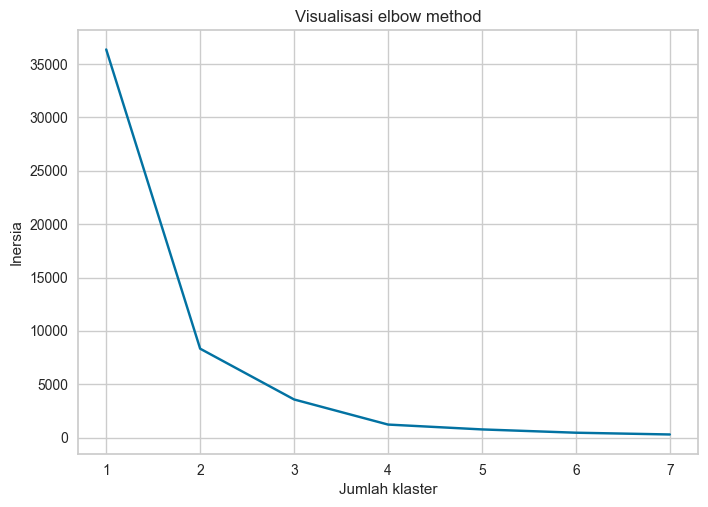

In [78]:
# Memvisualisasikan elbow method
inertia = []
for cluster in range(1, 8):
    km = KMeans(n_clusters=cluster, n_init=10)
    km = km.fit(cluster_df)
    inertia.append(km.inertia_)

plt.plot(range(1, 8), inertia, 'bx-')
plt.xlabel('Jumlah klaster')
plt.ylabel('Inersia')
plt.title('Visualisasi elbow method')
plt.show()

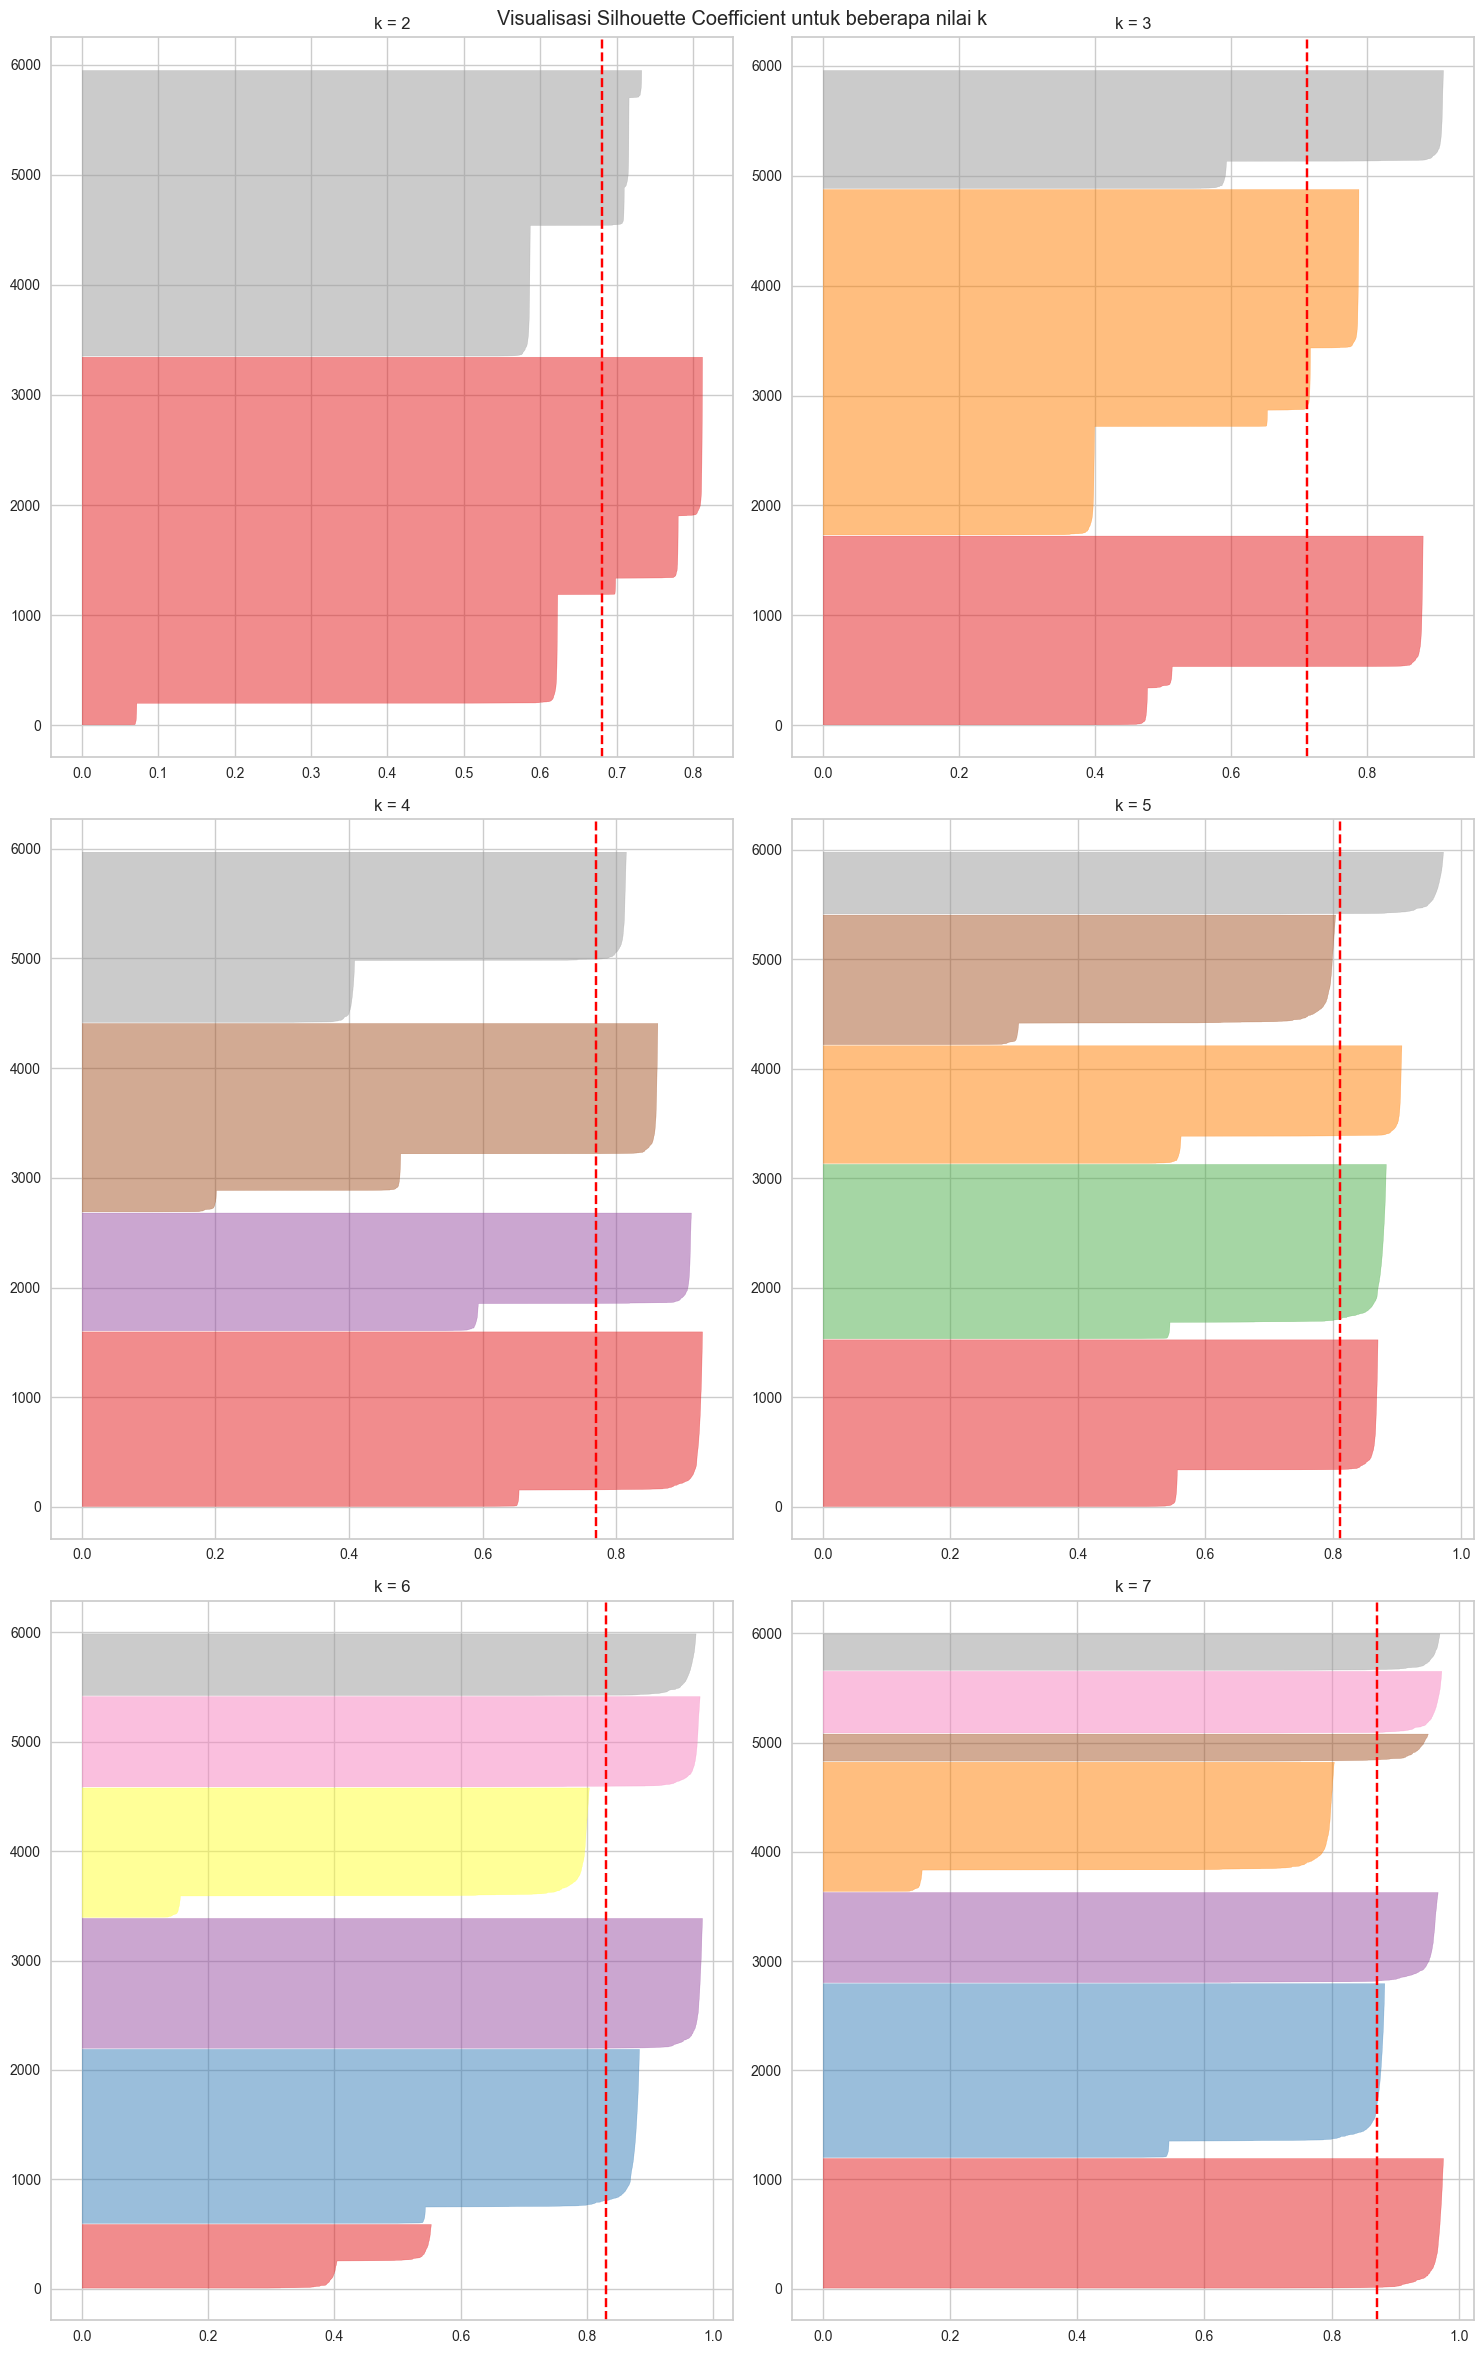

In [79]:
# Memvisualisasikan silhouette

fig, ax = plt.subplots(3, 2, figsize=(15, 24))  # Tambahkan grid yang lebih besar (4x2)
fig.suptitle("Visualisasi Silhouette Coefficient untuk beberapa nilai k")

for idx, k in enumerate(range(2, 8)):
    # Mendefinisikan model K-Means dengan nilai k tertentu
    clusterer = KMeans(n_clusters=k, n_init=10)

    # Hitung posisi subplot berdasarkan indeks
    row, col = divmod(idx, 2)
    ax[row][col].set_title(f"k = {k}")

    # Memvisualisasikan silhouette
    visualizer = SilhouetteVisualizer(clusterer, ax=ax[row][col])
    visualizer.fit(cluster_df)

plt.tight_layout()
plt.show()


In [80]:
# # Memvisualisasikan elbow method
# inertia = []
# for cluster in range(1, 10):
#     km = KMeans(n_clusters=cluster, n_init=10)
#     km = km.fit(cluster_df_ftrank)
#     inertia.append(km.inertia_)

# plt.plot(range(1, 10), inertia, 'bx-')
# plt.xlabel('Jumlah klaster')
# plt.ylabel('Inersia')
# plt.title('Visualisasi elbow method')
# plt.show()

In [81]:
# Memvisualisasikan silhouette

# fig, ax = plt.subplots(4, 2, figsize=(15, 24))  # Tambahkan grid yang lebih besar (4x2)
# fig.suptitle("Visualisasi Silhouette Coefficient untuk beberapa nilai k")

# for idx, k in enumerate(range(2, 10)):
#     # Mendefinisikan model K-Means dengan nilai k tertentu
#     clusterer = KMeans(n_clusters=k, n_init=10)

#     # Hitung posisi subplot berdasarkan indeks
#     row, col = divmod(idx, 2)
#     ax[row][col].set_title(f"k = {k}")

#     # Memvisualisasikan silhouette
#     visualizer = SilhouetteVisualizer(clusterer, ax=ax[row][col])
#     visualizer.fit(cluster_df_ftrank)

# plt.tight_layout()
# plt.show()


In [82]:
# Memvisualisasikan elbow method
# inertia = []
# for cluster in range(1, 10):
#     km = KMeans(n_clusters=cluster, n_init=10)
#     km = km.fit(cluster_n_r_as)
#     inertia.append(km.inertia_)

# plt.plot(range(1, 10), inertia, 'bx-')
# plt.xlabel('Jumlah klaster')
# plt.ylabel('Inersia')
# plt.title('Visualisasi elbow method')
# plt.show()

In [83]:
# Memvisualisasikan silhouette

# fig, ax = plt.subplots(4, 2, figsize=(15, 24))  # Tambahkan grid yang lebih besar (4x2)
# fig.suptitle("Visualisasi Silhouette Coefficient untuk beberapa nilai k")

# for idx, k in enumerate(range(2, 10)):
#     # Mendefinisikan model K-Means dengan nilai k tertentu
#     clusterer = KMeans(n_clusters=k, n_init=10)

#     # Hitung posisi subplot berdasarkan indeks
#     row, col = divmod(idx, 2)
#     ax[row][col].set_title(f"k = {k}")

#     # Memvisualisasikan silhouette
#     visualizer = SilhouetteVisualizer(clusterer, ax=ax[row][col])
#     visualizer.fit(cluster_n_r_as)

# plt.tight_layout()
# plt.show()


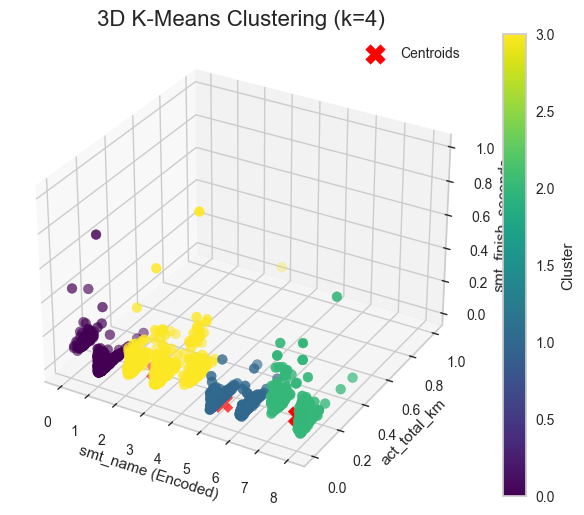

In [84]:
# Clustering with selected features and k
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(cluster_df)

# 3D Scatter Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot data points with cluster labels as colors
scatter = ax.scatter(
    cluster_df['smt_name'], 
    cluster_df['act_total_km'], 
    cluster_df['smt_finish_seconds'], 
    c=cluster_labels, 
    cmap='viridis', 
    s=50
)

# Plot centroids
centroids = kmeans.cluster_centers_
ax.scatter(
    centroids[:, 0], 
    centroids[:, 1], 
    centroids[:, 2], 
    c='red', 
    s=200, 
    marker='X', 
    label='Centroids'
)

# Labels and Title
ax.set_title('3D K-Means Clustering (k=4)', fontsize=16)
ax.set_xlabel('smt_name (Encoded)')
ax.set_ylabel('act_total_km')
ax.set_zlabel('smt_finish_seconds')
ax.legend()
plt.colorbar(scatter, ax=ax, label='Cluster')

plt.show()


In [85]:
# Clustering with selected features and k
# kmeans = KMeans(n_clusters=4, random_state=42)
# cluster_labels = kmeans.fit_predict(cluster_df_ftrank)

# # 3D Scatter Plot
# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111, projection='3d')

# # Plot data points with cluster labels as colors
# scatter = ax.scatter(
#     cluster_df_ftrank['smt_avg_spd'], 
#     cluster_df_ftrank['smt_finish_seconds'], 
#     cluster_df_ftrank['smt_rank'], 
#     c=cluster_labels, 
#     cmap='viridis', 
#     s=50
# )

# # Plot centroids
# centroids = kmeans.cluster_centers_
# ax.scatter(
#     centroids[:, 0], 
#     centroids[:, 1], 
#     centroids[:, 2], 
#     c='red', 
#     s=200, 
#     marker='X', 
#     label='Centroids'
# )

# # Labels and Title
# ax.set_title('3D K-Means Clustering (k=4)', fontsize=16)
# ax.set_xlabel('smt_avg_spd')
# ax.set_ylabel('smt_finish_seconds')
# ax.set_zlabel('smt_rank')
# ax.legend()
# plt.colorbar(scatter, ax=ax, label='Cluster')

# plt.show()


In [86]:
# Clustering with selected features and k
# kmeans = KMeans(n_clusters=4, random_state=42)
# cluster_labels = kmeans.fit_predict(cluster_n_r_as)

# # 3D Scatter Plot
# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111, projection='3d')

# # Plot data points with cluster labels as colors
# scatter = ax.scatter(
#     cluster_n_r_as['smt_rank'], 
#     cluster_n_r_as['smt_avg_spd'], 
#     cluster_n_r_as['smt_name'], 
#     c=cluster_labels, 
#     cmap='viridis', 
#     s=50
# )

# # Plot centroids
# centroids = kmeans.cluster_centers_
# ax.scatter(
#     centroids[:, 0], 
#     centroids[:, 1], 
#     centroids[:, 2], 
#     c='red', 
#     s=200, 
#     marker='X', 
#     label='Centroids'
# )

# # Labels and Title
# ax.set_title('3D K-Means Clustering (k=4)', fontsize=16)
# ax.set_xlabel('smt_rank')
# ax.set_ylabel('smt_avg_spd')
# ax.set_zlabel('smt_name (Encoded)')
# ax.legend()
# plt.colorbar(scatter, ax=ax, label='Cluster')

# plt.show()


In [87]:
# General clustering with PCA for visual
# kmeans = KMeans(n_clusters=3, random_state=42)
# cluster_labels = kmeans.fit_predict(scaled_df)
# pca = PCA(n_components=3)
# preproc_pca = pca.fit_transform(scaled_df)

# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111, projection='3d')

# scatter = ax.scatter(preproc_pca[:, 0], preproc_pca[:, 1], preproc_pca[:, 2],
#                      c=cluster_labels, cmap='viridis', s=50)

# pc_names = [f"PC{i+1}" for i in range(3)]
# print("Top 3 PCs:", pc_names)

# ax.set_title("3D Cluster Visualization (PCA-Reduced Features)")
# ax.set_xlabel("Principal Component 1")
# ax.set_ylabel("Principal Component 2")
# ax.set_zlabel("Principal Component 3")
# plt.colorbar(scatter)

# plt.show()


### Pearson Correlation (Unused)

In [88]:
df_corr_matrix_prep = preproc_df.copy()
display(df_corr_matrix_prep)


,user_age_group,gender,smt_rank,smt_avg_spd,smt_finish_seconds,smt_name,user_weight_category,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data
0,2,1,712,15.8,382,1,0,13.6,34.9,19.24,5103,5103,0
1,2,1,189,33.2,216,5,6,21.5,43.2,23.47,3926,3926,0
2,2,1,264,23.7,593,8,3,26.7,92.9,38.23,5152,5152,0
3,2,1,50,33.4,817,0,3,31.4,54.4,65.77,7548,7548,1
4,2,0,19,21.3,284,1,0,19.9,43.2,96.53,17493,17493,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6286,2,1,396,24.2,718,3,0,16.6,34.9,41.34,8970,8970,0
6288,3,1,34,38.9,446,3,4,34.5,52.2,48.13,5026,5026,1
6289,3,1,218,22.1,637,8,3,17.6,40.7,50.64,10374,10374,0
6290,3,1,477,12.4,485,1,4,14.5,34.9,40.93,10158,10158,0


In [89]:
correlation_matrix = df_corr_matrix_prep.corr(method='pearson')
display(correlation_matrix)

,user_age_group,gender,smt_rank,smt_avg_spd,smt_finish_seconds,smt_name,user_weight_category,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data
user_age_group,1.000000,0.051224,-0.096144,0.085180,-0.003285,0.027487,0.145269,0.068077,-0.031839,0.093602,0.018452,0.018452,0.124824
gender,0.051224,1.000000,0.189453,0.151595,-0.041152,0.061795,0.165876,0.145189,0.118647,0.060370,0.006144,0.006144,-0.005302
smt_rank,-0.096144,0.189453,1.000000,-0.548301,0.013785,-0.138305,-0.047148,-0.503859,-0.180300,-0.291762,-0.003440,-0.003440,-0.219836
smt_avg_spd,0.085180,0.151595,-0.548301,1.000000,-0.422577,0.097293,0.150851,0.699424,0.313167,0.241420,-0.018608,-0.018608,0.281081
smt_finish_seconds,-0.003285,-0.041152,0.013785,-0.422577,1.000000,0.144179,-0.016325,-0.150932,-0.003911,0.178007,0.038995,0.038995,-0.034007
smt_name,0.027487,0.061795,-0.138305,0.097293,0.144179,1.000000,0.057488,0.079780,0.059409,0.064191,0.022752,0.022752,0.003428
user_weight_category,0.145269,0.165876,-0.047148,0.150851,-0.016325,0.057488,1.000000,0.138068,0.032438,0.036133,-0.021968,-0.021968,0.114576
act_avg_spd,0.068077,0.145189,-0.503859,0.699424,-0.150932,0.079780,0.138068,1.000000,0.316751,0.350472,-0.096774,-0.096774,0.397024
act_max_spd,-0.031839,0.118647,-0.180300,0.313167,-0.003911,0.059409,0.032438,0.316751,1.000000,0.293332,0.008867,0.008867,0.026610
act_total_km,0.093602,0.060370,-0.291762,0.241420,0.178007,0.064191,0.036133,0.350472,0.293332,1.000000,0.095276,0.095276,0.189727


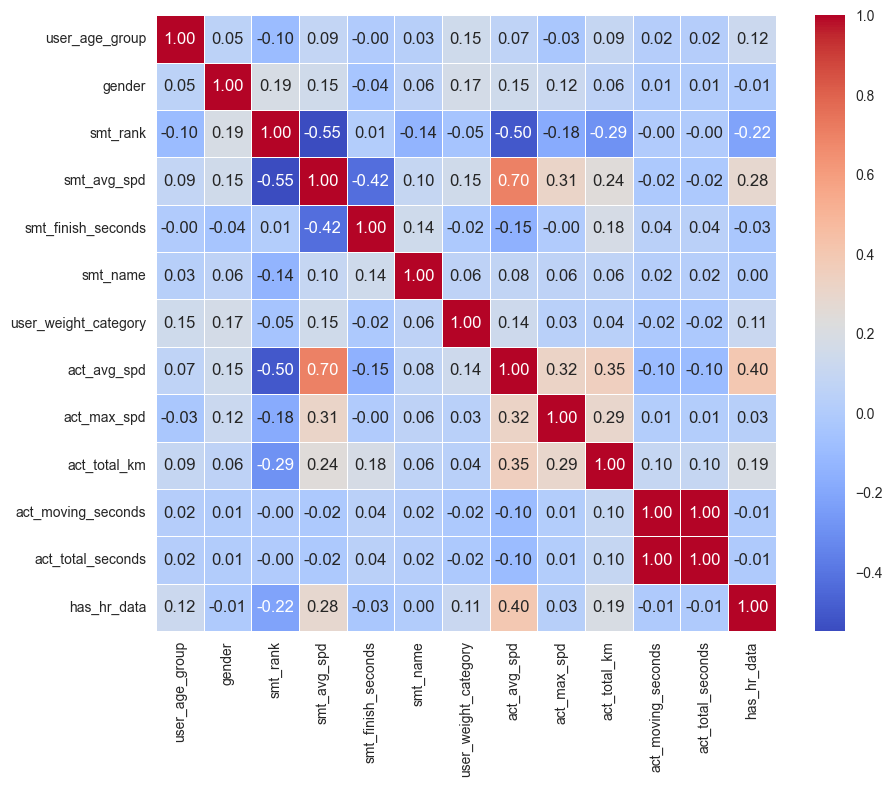

In [90]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")

plt.show()